In [1]:
import xarray as xr 
import numpy as np
from Plot_2D import Plot_2D
import matplotlib.pyplot as plt

In [ ]:
path = '../util_data/'
file = 'FWmaHIST_ne0CONUSne30x8_ne0CONUSne30x8_mt12_no_conus_gravity_waves_lat_lon_area.nc'
ds = xr.open_dataset(path + file)

In [3]:
ds['T'].isel(time=0).squeeze()

<xarray.DataArray 'T' (ncol: 174098)> Size: 696kB
[174098 values with dtype=float32]
Coordinates:
    lev      float64 8B 6.14e-06
    time     object 8B 2010-12-01 00:00:00
Dimensions without coordinates: ncol
Attributes:
    mdims:      1
    units:      K
    long_name:  Temperature

In [4]:
scrip_file = '../util_data/ne0CONUS_ne30x8_np4_SCRIP.nc'

In [5]:
# Function to plot boxes on a map

from shapely.geometry import LineString

def lat_line_plot(latval,lonL,lonU, ax, usr_color):
    latitude_line = [(lon, latval) for lon in range(lonL, lonU+1)]
    line_geometry = LineString(latitude_line)
    ax.plot(*line_geometry.xy, transform=ccrs.PlateCarree(), color=usr_color, linewidth=1)

def lon_line_plot(lonval, latL, latU, ax, usr_color):
    latitude_line = [(lonval, lat) for lat in range(latL, latU+1)]
    line_geometry = LineString(latitude_line)
    ax.plot(*line_geometry.xy, transform=ccrs.PlateCarree(), color=usr_color, linewidth=1)

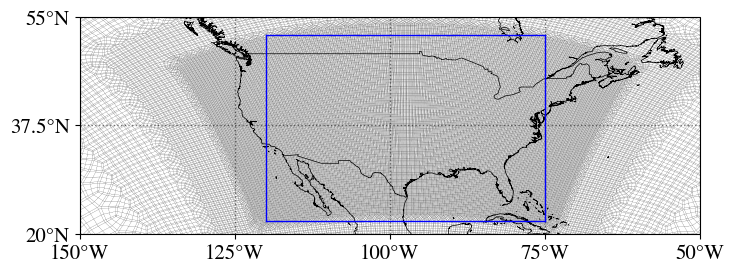

In [44]:
import cartopy.crs as ccrs

Plot_2D(ds['T'].isel(time=0,lev=0)*0.0001,grid_line=True,grid_line_lw=0.07,
        lon_range=[-150,-50],lat_range=[20,55],cmin=5,scrip_file=scrip_file,cmap='Greys')

ax = plt.gca()

latL = 22
latU = 52
lonL = -120
lonU = -75

lat_line_plot(latL,lonL,lonU,ax,usr_color='blue')
lat_line_plot(latU,lonL,lonU,ax,usr_color='blue')
lon_line_plot(lonL,latL,latU,ax,usr_color='blue')
lon_line_plot(lonU,latL,latU,ax,usr_color='blue')

ax.set_xticks(np.arange(-150,-25,25))
ax.set_yticks([20,37.5,55])

fig = ax.figure
fig.axes[1].remove() # removes colorbar